# Bài tập Thực hành 2: Huấn luyện Mô hình Phân loại Tín hiệu Âm thanh với 1D CNN (Audio Classification)

Trong bài tập này, các bạn sẽ thực hành xây dựng quy trình Deep Learning phân loại giọng nói từ dữ liệu sóng âm thanh thời gian (Raw Waveform) sử dụng mạng tích phân 1 chiều (**1D CNN**) trên bộ dữ liệu **Speech Commands**:

1. **Tải và Đọc bộ dữ liệu bên ngoài**: Tải bộ dữ liệu `Speech Commands` từ TensorFlow Storage, giải nén và nạp các file âm thanh `.wav` của 4 lệnh giọng nói (`go`, `stop`, `yes`, `no`).
2. **Chuẩn bị Dữ liệu dạng Sóng 1D (Raw Waveform)**: Đọc tín hiệu thời gian dạng sóng 1D (độ dài 16,000 samples = 1.0s ở tần số lấy mẫu 16kHz) không qua biến đổi phổ STFT.
3. **Tiền xử lý & Đóng gói dữ liệu**: Định hình dữ liệu dạng tensor 3D `(batch_size, 1, sequence_length)` cho PyTorch 1D CNN, phân chia tập Train/Test và đóng gói vào PyTorch `DataLoader`.
4. **Xây dựng Mô hình (Model Architecture)**: Định nghĩa mạng tích phân 1 chiều (**1D CNN**) bằng PyTorch (`nn.Conv1d`, `nn.BatchNorm1d`, `nn.MaxPool1d`, `nn.AdaptiveAvgPool1d`, `nn.Linear`).
5. **Huấn luyện Mô hình (Training Loop)**: Cấu hình Loss Function (`CrossEntropyLoss`), Optimizer (`Adam`) và viết vòng lặp huấn luyện qua nhiều epochs.
6. **Đánh giá & Trực quan hóa**: Vẽ đồ thị đường cong học tập (Learning curves), báo cáo phân loại (Classification Report) và ma trận nhầm lẫn (Confusion Matrix).
7. **Câu hỏi thảo luận**: Trả lời câu hỏi phân tích về những hạn chế cốt lõi của mô hình 1D CNN khi xử lý trực tiếp tín hiệu dạng sóng thời gian (Raw Waveform).


## 1. Import các thư viện cần thiết
Chạy cell dưới đây để nạp các thư viện cơ bản cho đọc file/tải dữ liệu (`urllib`, `zipfile`, `glob`), xử lý tín hiệu âm thanh (`librosa`), học sâu (`torch`), tiền xử lý/đánh giá (`sklearn`) và trực quan hóa (`matplotlib`, `seaborn`).


In [4]:
# Chạy lệnh này trong terminal nếu chưa cài đặt thư viện:
# pip install torch librosa numpy matplotlib scikit-learn seaborn

import os
import glob
import zipfile
import urllib.request
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except ImportError:
    try:
        from tqdm import tqdm
    except ImportError:
        tqdm = None

# Cấu hình seed ngẫu nhiên để kết quả có tính tái lập (reproducible)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Librosa version: {librosa.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Librosa version: 0.11.0
Using device: cuda


## 2. Tải và Nạp Bộ Dữ liệu Âm thanh Bên ngoài (Speech Commands Dataset)
Chúng ta sẽ tải bộ dữ liệu lệnh giọng nói thực tế **Mini Speech Commands Dataset** từ nguồn bên ngoài.
Bộ dữ liệu gồm 4 lớp từ lệnh giọng nói: `go`, `stop`, `yes`, `no`. Mỗi mẫu âm thanh có tần số lấy mẫu \(sr = 16000\) Hz và thời lượng 1.0 giây (tương ứng 16,000 mẫu số liệu dạng sóng 1D).


In [5]:
# TODO 1: Tải bộ dữ liệu bên ngoài, giải nén và nạp các file âm thanh .wav
# Yêu cầu:
# - URL dataset: 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
# - Tải file zip nếu chưa tồn tại và giải nén vào thư mục 'dataset_speech_commands'.
# - Chọn 4 lớp âm thanh: target_classes = ['go', 'stop', 'yes', 'no'].
# - Đọc tối đa max_samples_per_class = 150 mẫu mỗi lớp bằng librosa.load(..., sr=16000, duration=1.0).
# - Nếu mảng tín hiệu dài chưa đủ 16000 samples, đệm số 0 (np.pad) cho đủ 16000 samples.
#
# Đầu ra:
# - X_audio: danh sách chứa các mảng tín hiệu âm thanh dạng sóng 1D (mỗi mảng có độ dài 16000).
# - y_labels: danh sách chứa nhãn từ 0 đến 3.

url = 'https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
zip_path = 'mini_speech_commands.zip'
extract_dir = './1dcnn (2)/dataset_speech_commands'

if not os.path.exists(zip_path):
    print("Đang tải dữ liệu Speech Commands từ internet...")
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists(extract_dir):
    print("Đang giải nén bộ dữ liệu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

dataset_dir = os.path.join(extract_dir, 'mini_speech_commands')
target_classes = ['go', 'stop', 'yes', 'no']
max_samples_per_class = 150

X_audio = []
y_labels = []

# Bước 2: Điền code đọc các file âm thanh vào X_audio và y_labels tại đây:
for label, class_name in enumerate(target_classes):
      class_dir = os.path.join(dataset_dir, class_name)
      wav_files = sorted(glob.glob(os.path.join(class_dir, "*.wav")))

      for wav_path in wav_files[:max_samples_per_class]:
          signal, _ = librosa.load(wav_path, sr=16000, duration=1.0)

          # Nếu ngắn hơn 1 giây thì thêm số 0 ở cuối
          if len(signal) < 16000:
              signal = np.pad(signal, (0, 16000 - len(signal)))
          else:
              signal = signal[:16000]

          X_audio.append(signal)
          y_labels.append(label)



print(f"Tổng số mẫu âm thanh đã nạp: {len(X_audio)}")
print(f"Độ dài mỗi mẫu âm thanh: {len(X_audio[0]) if len(X_audio) > 0 else 0} samples")


Tổng số mẫu âm thanh đã nạp: 600
Độ dài mỗi mẫu âm thanh: 16000 samples


## 3. Tiền xử lý dữ liệu sóng & Tạo PyTorch DataLoader
1. Chuyển `X_audio` thành numpy array và định hình lại theo chuẩn input của PyTorch 1D CNN: **`(batch_size, num_channels, sequence_length)`** -> **`(N, 1, 16000)`**.
2. Chia dữ liệu thành tập **Train (80%)** và tập **Test (20%)** giữ nguyên tỉ lệ lớp (`stratify=y_labels`, `random_state=SEED`).
3. Chuyển mảng NumPy thành `torch.Tensor` (`float32` cho X, `long` cho y).
4. Đóng gói vào `TensorDataset` và `DataLoader` với `batch_size = 16` (`shuffle=True` cho tập Train).


In [6]:
# TODO 2: Định hình lại dữ liệu, phân chia tập Train/Test và tạo DataLoader
# Gợi ý:
# - Chuyển X_audio thành mảng numpy kích thước (N, 16000), sau đó dùng np.expand_dims(..., axis=1) để được kích thước (N, 1, 16000)
# - Sử dụng train_test_split(..., test_size=0.2, random_state=SEED, stratify=y_labels)
# - Chuyển sang Tensor: torch.tensor(..., dtype=torch.float32) và torch.tensor(..., dtype=torch.long)
# - Tạo TensorDataset và DataLoader(..., batch_size=16)

# Điền code tiền xử lý và đóng gói DataLoader ở đây:
X = np.array(X_audio, dtype=np.float32)        # (N, 16000)
X = np.expand_dims(X, axis=1)                  # (N, 1, 16000)
y = np.array(y_labels, dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
  )

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



print(f"Kích thước tập Train (X_train): {X_train.shape if X_train is not None else 0}")
print(f"Kích thước tập Test (X_test): {X_test.shape if X_test is not None else 0}")


Kích thước tập Train (X_train): (480, 1, 16000)
Kích thước tập Test (X_test): (120, 1, 16000)


## 4. Xây dựng Kiến trúc Mô hình 1D CNN (AudioCNN1D)
Thiết kế mạng nơ-ron tích phân 1 chiều (1D CNN) thích hợp để tự động trích xuất đặc trưng từ dạng sóng âm thanh 1D (độ dài 16,000 mẫu):
- **Convolutional Feature Extractor**:
  - **Block 1**: `Conv1d(1, 16, kernel_size=64, stride=4, padding=30)` -> `BatchNorm1d(16)` -> `ReLU()` -> `MaxPool1d(kernel_size=4)`
  - **Block 2**: `Conv1d(16, 32, kernel_size=32, stride=2, padding=15)` -> `BatchNorm1d(32)` -> `ReLU()` -> `MaxPool1d(kernel_size=4)`
  - **Block 3**: `Conv1d(32, 64, kernel_size=16, stride=2, padding=7)` -> `BatchNorm1d(64)` -> `ReLU()` -> `MaxPool1d(kernel_size=2)`
  - **Block 4**: `Conv1d(64, 128, kernel_size=8, stride=1, padding=4)` -> `BatchNorm1d(128)` -> `ReLU()` -> `AdaptiveAvgPool1d(1)`
- **Classifier Header**:
  - `Flatten()` -> `Linear(128, 64)` -> `ReLU()` -> `Dropout(0.3)` -> `Linear(64, num_classes=4)`.


In [7]:
# TODO 3: Định nghĩa lớp mô hình AudioCNN1D kế thừa từ nn.Module

class AudioCNN1D(nn.Module):
      def __init__(self, num_classes=4):
          super(AudioCNN1D, self).__init__()

          self.features = nn.Sequential(
              nn.Conv1d(1, 16, kernel_size=64, stride=4, padding=30),
              nn.BatchNorm1d(16),
              nn.ReLU(),
              nn.MaxPool1d(kernel_size=4),

              nn.Conv1d(16, 32, kernel_size=32, stride=2, padding=15),
              nn.BatchNorm1d(32),
              nn.ReLU(),
              nn.MaxPool1d(kernel_size=4),

              nn.Conv1d(32, 64, kernel_size=16, stride=2, padding=7),
              nn.BatchNorm1d(64),
              nn.ReLU(),
              nn.MaxPool1d(kernel_size=2),

              nn.Conv1d(64, 128, kernel_size=8, stride=1, padding=4),
              nn.BatchNorm1d(128),
              nn.ReLU(),
              nn.AdaptiveAvgPool1d(1)
          )

          self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(128, 64),
              nn.ReLU(),
              nn.Dropout(0.3),
              nn.Linear(64, num_classes)
          )

      def forward(self, x):
          x = self.features(x)
          return self.classifier(x)

# Khởi tạo mô hình và chuyển sang thiết bị tính toán (CPU/GPU)
model = AudioCNN1D(num_classes=4).to(device)
print(model)


AudioCNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(64,), stride=(4,), padding=(30,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(32,), stride=(2,), padding=(15,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(16,), stride=(2,), padding=(7,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(8,), stride=(1,), padding=(4,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
   

## 5. Cấu hình Loss Function & Optimizer
Với bài toán phân loại đa lớp:
- **Loss Function**: `nn.CrossEntropyLoss()`
- **Optimizer**: `optim.Adam()` với `learning_rate = 0.001`.


In [8]:
# TODO 4: Khởi tạo Criterion (Loss Function) và Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Hàm mất mát và Thuật toán tối ưu đã khởi tạo thành công.")


Hàm mất mát và Thuật toán tối ưu đã khởi tạo thành công.


## 6. Huấn luyện Mô hình (Training Loop)
Thực hiện huấn luyện mô hình qua **25 Epochs**.
Ghi lại lịch sử loss và accuracy trên cả 2 tập Train và Test sau mỗi epoch.


In [9]:
# TODO 5: Viết vòng lặp huấn luyện mô hình qua 25 Epochs
# Lưu lịch sử loss & accuracy vào các mảng: train_losses, test_losses, train_accs, test_accs

epochs = 25
train_losses, test_losses = [], []
train_accs, test_accs = [], []

# Điền vòng lặp huấn luyện vào đây:

for epoch in range(epochs):
      # Huấn luyện
      model.train()
      train_loss_sum = 0.0
      train_correct = 0
      train_total = 0

      train_iter = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [train]", leave=False) if tqdm is not None else train_loader
      for X_batch, y_batch in train_iter:
          X_batch = X_batch.to(device)
          y_batch = y_batch.to(device)

          optimizer.zero_grad()
          outputs = model(X_batch)
          loss = criterion(outputs, y_batch)
          loss.backward()
          optimizer.step()

          train_loss_sum += loss.item() * X_batch.size(0)
          predictions = torch.argmax(outputs, dim=1)
          train_correct += (predictions == y_batch).sum().item()
          train_total += y_batch.size(0)

          if tqdm is not None:
              current_loss = train_loss_sum / max(1, train_total)
              current_acc = train_correct / max(1, train_total)
              train_iter.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.4f}")

      train_loss = train_loss_sum / train_total
      train_acc = train_correct / train_total

      # Đánh giá trên test
      model.eval()
      test_loss_sum = 0.0
      test_correct = 0
      test_total = 0

      test_iter = tqdm(test_loader, desc=f"Epoch {epoch + 1}/{epochs} [test]", leave=False) if tqdm is not None else test_loader
      with torch.no_grad():
          for X_batch, y_batch in test_iter:
              X_batch = X_batch.to(device)
              y_batch = y_batch.to(device)

              outputs = model(X_batch)
              loss = criterion(outputs, y_batch)

              test_loss_sum += loss.item() * X_batch.size(0)
              predictions = torch.argmax(outputs, dim=1)
              test_correct += (predictions == y_batch).sum().item()
              test_total += y_batch.size(0)

              if tqdm is not None:
                  current_loss = test_loss_sum / max(1, test_total)
                  current_acc = test_correct / max(1, test_total)
                  test_iter.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.4f}")

      test_loss = test_loss_sum / test_total
      test_acc = test_correct / test_total

      train_losses.append(train_loss)
      test_losses.append(test_loss)
      train_accs.append(train_acc)
      test_accs.append(test_acc)

      print(
          f"Epoch [{epoch + 1}/{epochs}] - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
      )

Epoch 1/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/25 [test]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [1/25] - Train Loss: 1.3565, Train Acc: 0.3604 | Test Loss: 1.3638, Test Acc: 0.3000


Epoch 2/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 2/25 [test]:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 24/25 [test]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [24/25] - Train Loss: 0.2048, Train Acc: 0.9396 | Test Loss: 1.0214, Test Acc: 0.7083


Epoch 25/25 [train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 25/25 [test]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [25/25] - Train Loss: 0.2002, Train Acc: 0.9417 | Test Loss: 0.3513, Test Acc: 0.8750


## 7. Đánh giá Mô hình & Trực quan hóa Kết quả
1. Vẽ biểu đồ diễn biến **Loss** và **Accuracy** trên 2 tập Train/Test theo Epochs.
2. Hiển thị **Classification Report** (Precision, Recall, F1-score) cho 4 lớp từ lệnh giọng nói (`go`, `stop`, `yes`, `no`).
3. Vẽ **Ma trận nhầm lẫn (Confusion Matrix)** bằng Heatmap của `seaborn`.


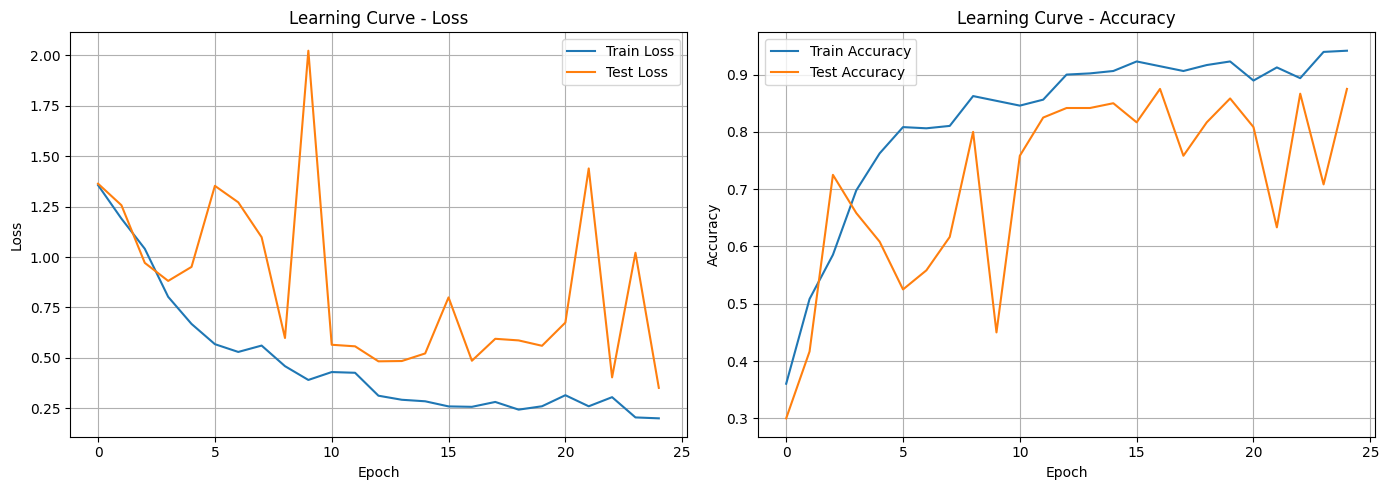

              precision    recall  f1-score   support

          go       0.79      0.87      0.83        30
        stop       0.87      0.90      0.89        30
         yes       1.00      0.87      0.93        30
          no       0.87      0.87      0.87        30

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120



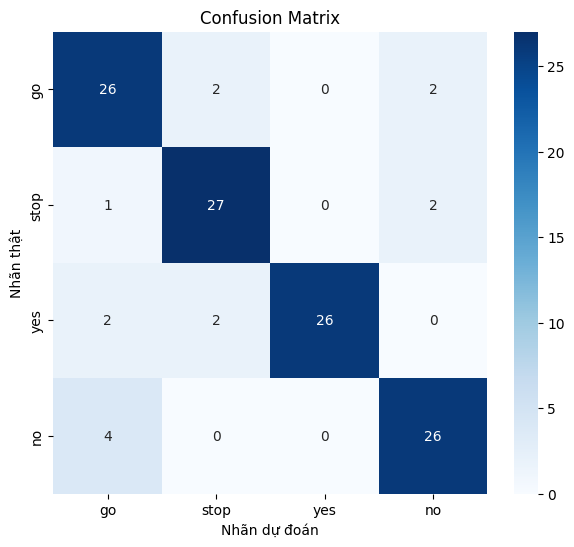

In [10]:
# TODO 6: Vẽ đồ thị quá trình huấn luyện và ma trận nhầm lẫn

# Điền code vẽ đồ thị và trực quan hóa kết quả ở đây:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

  # Dự đoán trên tập test
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predictions.cpu().numpy())

  # Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=target_classes
))

  # Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_classes,
    yticklabels=target_classes
  )
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thật")
plt.title("Confusion Matrix")
plt.show()





## 8. Câu hỏi thảo luận & Mở rộng

**Câu hỏi:** Hãy phân tích những **hạn chế chính** của việc huấn luyện mô hình 1D CNN xử lý trực tiếp tín hiệu dạng sóng âm thanh thời gian (Raw Waveform) so với việc trích xuất đặc trưng phổ thời gian - tần số (như STFT Spectrogram hay MFCC)?

*Trả lời của sinh viên:*

Huấn luyện 1D CNN trực tiếp trên raw waveform có ưu điểm là tránh phải thiết kế đặc trưng thủ công, nhưng thường gặp một số hạn chế chính sau:

1. **Khó học đặc trưng thời gian–tần số:** Tín hiệu sóng biểu diễn biên độ theo thời gian, còn thông tin quan trọng để nhận dạng lệnh nói (cao độ, formant, năng lượng theo dải tần) nằm rõ hơn ở miền tần số. 1D CNN phải tự học phép biến đổi tương tự STFT/MFCC từ dữ liệu, nên khó hơn và cần nhiều tầng/dữ liệu hơn.
2. **Nhạy với dịch thời gian và nhiễu:** Vị trí bắt đầu câu nói, tốc độ nói, pha tín hiệu, tiếng ồn và âm lượng thay đổi có thể làm waveform khác đáng kể. Spectrogram hoặc MFCC thường ổn định hơn vì phân tích tín hiệu theo các khung ngắn và tập trung vào năng lượng phổ.
3. **Chi phí tính toán và bộ nhớ lớn:** Với cùng thời lượng âm thanh, waveform có số mẫu rất lớn (ví dụ 16.000 mẫu/giây). Do đó 1D CNN phải xử lý chuỗi dài, làm tăng chi phí huấn luyện và khó mở rộng receptive field để nắm ngữ cảnh dài.
4. **Cần nhiều dữ liệu để tổng quát hóa:** STFT/MFCC đưa vào mô hình các đặc trưng đã có ý nghĩa vật lý và phù hợp với cảm nhận âm thanh của con người; đây là một dạng kiến thức tiền nghiệm. Raw waveform ít có cấu trúc sẵn, nên mô hình dễ overfit khi dữ liệu huấn luyện nhỏ.

Vì vậy, với bài toán nhận dạng lệnh nói có dữ liệu và tài nguyên hạn chế, STFT Spectrogram hoặc MFCC thường giúp mô hình hội tụ nhanh và ổn định hơn. Raw waveform phù hợp hơn khi có dữ liệu lớn, kiến trúc đủ mạnh và muốn mô hình tự học đặc trưng tối ưu từ đầu đến cuối.
